# Week 1 Lab – Part 2: Multiple Features and Polynomial Regression (House Prices)

In the previous notebooks, we predicted a target value using **one feature**:

$$
f_{w,b}(x) = wx + b
$$

In many real problems, one feature is not enough.

For example, if we want to estimate the price of a house, we may want to use:

- `size_m2`: larger houses usually cost more,
- `bedrooms`: more bedrooms may increase the price,
- `front_m`: the width of the lot may matter,
- `depth_m`: the depth of the lot may matter.

A few example rows might look like this:

| size_m2 | bedrooms | front_m | depth_m | price_k |
|---------|----------|---------|---------|---------|
| 80 | 2 | 7 | 12 | 220 |
| 120 | 3 | 9 | 18 | 310 |
| 180 | 4 | 12 | 22 | 450 |

The goal is the same as before: learn parameters that help us make good predictions. The difference is that each example now has several input values instead of just one.

We keep the same notation as in class:

- The $i$-th training example is $(x^{(i)}, y^{(i)})$.
- Each input $x^{(i)}$ has $n$ features:
  $$
  x^{(i)} = \big[x_1^{(i)}, x_2^{(i)}, \dots, x_n^{(i)}\big].
  $$
- The model is:
  $$
  f_{w,b}(x) = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b.
  $$

In this notebook, we will first build a multifeature linear regression model. Then we will explore two extensions: **feature engineering** and **polynomial regression**.


## 0.1 Linear Regression with Multiple Features

For one feature we had
$$
f_{w,b}(x) = wx + b.
$$

For **multiple features**, with $\vec{x} \in \mathbb{R}^n$ and $\vec{w} \in \mathbb{R}^n$, we write
$$
f_{\vec{w}, b}(\vec{x}) = \sum_{j=1}^{n} w_j x_j + b.
$$

In **vector notation** this becomes
$$
f_{\vec{w}, b}(\vec{x}) = \vec{w}^T \vec{x} + b.
$$

For a whole dataset with $m$ examples, we collect the inputs into a **design matrix** $\mathbf{X} \in \mathbb{R}^{m \times n}$:
- Row $i$ of $\mathbf{X}$ is $(x_1^{(i)}, \dots, x_n^{(i)})$.
- The target vector is $\vec{y} \in \mathbb{R}^m$, with entries $y^{(i)}$.

Then the predictions for all examples at once are
$$
\hat{\vec{y}} = \mathbf{X} \vec{w} + b \,\vec{1},
$$
where $\vec{1}$ is the vector of all ones (size $m$).


## 0.2 Cost Function for Multiple Features

The cost function is the same **mean squared error** we used before, now written for the multivariate case:

$$
J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \right)^2.
$$


## 0.3 Gradient Descent for Multiple Features

The partial derivatives of $J(\vec{w}, b)$ are:

- For each $w_j$:
  $$
  \frac{\partial J(\vec{w}, b)}{\partial w_j} 
  = \frac{1}{m} \sum_{i=1}^{m} \big( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \big)\, x_j^{(i)}.
  $$

- For the bias term $b$:
  $$
  \frac{\partial J(\vec{w}, b)}{\partial b} 
  = \frac{1}{m} \sum_{i=1}^{m} \big( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \big).
  $$

In **vector/matrix form**, let
- $\hat{\vec{y}} = f_{\vec{w}, b}(\mathbf{X})$ (the vector of predictions),
- $\vec{e} = \hat{\vec{y}} - \vec{y}$ (the error vector).

Then:
$$
\nabla_{\vec{w}} J(\vec{w}, b) 
= \frac{1}{m} \,\mathbf{X}^T \vec{e},
\qquad
\frac{\partial J(\vec{w}, b)}{\partial b}
= \frac{1}{m} \sum_{i=1}^{m} e^{(i)}.
$$

The gradient descent updates are:
$$
\vec{w} := \vec{w} - \alpha \, \nabla_{\vec{w}} J(\vec{w}, b),
\qquad
b := b - \alpha \, \frac{\partial J(\vec{w}, b)}{\partial b},
$$
where $\alpha$ is the learning rate.


## 1. Setup


In [1]:

# Install required libraries (run this once if needed)
%pip install numpy pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 25.0 MB/s  0:00:0025.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Make NumPy output easier to read.
np.set_printoptions(precision=4, suppress=True)


## 2. A Simple House Prices Dataset

We will simulate a small house-price dataset with the following features:

- $x_1$ = `size_m2` (size of the house in square meters),
- $x_2$ = `bedrooms` (number of bedrooms),
- $x_3$ = `front_m` (front of the lot in meters),
- $x_4$ = `depth_m` (depth of the lot in meters).

The target $y$ is the house price in thousands of dollars, stored as `price_k`.

We use `pandas` only to inspect the table more comfortably. The model itself uses NumPy arrays.


In [3]:
# Number of examples.
m = 80

# Random generator for reproducible results.
rng = np.random.default_rng(0)

# Create each feature as a NumPy array with m values.
size_m2 = rng.uniform(50, 200, m)        # 50 to 200 square meters
bedrooms = rng.integers(1, 5, m)         # 1 to 4 bedrooms
front_m = rng.uniform(5, 15, m)          # 5 to 15 meters
depth_m = rng.uniform(8, 25, m)          # 8 to 25 meters

# "True" underlying parameters used only to generate the example data.
# The learning algorithm does not know these values.
feature_names = ["size_m2", "bedrooms", "front_m", "depth_m"]
true_w = np.array([1.5, 10.0, 3.0, 2.0])
true_b = 50.0

# Add random noise so the data is not perfectly linear.
noise = rng.normal(0, 10, m)

# Build the design matrix X.
# Each row is one house. Each column is one feature.
X = np.column_stack([size_m2, bedrooms, front_m, depth_m])

# Vectorized target generation:
# X @ true_w computes the weighted sum for all houses at once.
y = X @ true_w + true_b + noise

# Put the data into a DataFrame just to inspect it as a table.
data = pd.DataFrame({
    "size_m2": size_m2,
    "bedrooms": bedrooms,
    "front_m": front_m,
    "depth_m": depth_m,
    "price_k": y,
})

data.head()


,size_m2,bedrooms,front_m,depth_m,price_k
0,145.544253,4,8.443100,13.434588,360.297946
1,90.468007,4,9.302987,11.187631,276.333513
2,56.146029,2,14.660621,19.432953,229.623205
3,52.479145,2,10.622318,11.316826,190.353580
4,171.990536,2,7.588646,17.820694,400.616915


### 2.1 Visualize Size vs Price

A scatter plot with one feature can still be useful. Here we look only at `size_m2` versus price, even though the model will use all four features.


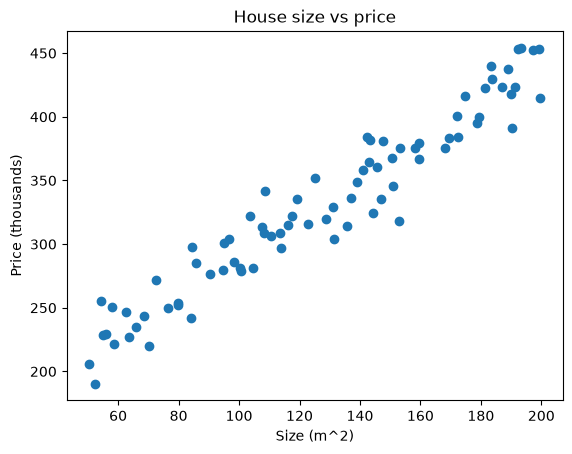

In [4]:
plt.figure()
plt.scatter(data["size_m2"], data["price_k"])
plt.xlabel("Size (m^2)")
plt.ylabel("Price (thousands)")
plt.title("House size vs price")
plt.show()


## 3. Vectorized Model Implementation

We now implement the model and cost function using **NumPy arrays** and **vectorized operations**.

### 3.1 Hypothesis $f_{w,b}(x)$

For one house with four features, the model is:

$$
f_{w,b}(x) = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b
$$

For all houses at once, the vectorized formula is:

$$
\hat{y} = Xw + b
$$

In NumPy, `X @ w` means matrix-vector multiplication.


In [5]:
def predict(X, w, b):
    """Compute predictions f_{w,b}(x) for all examples.

    X has shape (m, n): m houses and n features.
    w has shape (n,): one weight per feature.
    b is a scalar bias term.
    """
    # X @ w computes one weighted sum per row of X.
    # Adding b shifts every prediction by the same amount.
    return X @ w + b



### 3.2 Cost Function $J(w,b)$ (Vectorized)

We recall
$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2.
$$

In vector form, if we define the error vector $e = \hat{y} - y$, then
$$
J(w,b) = \frac{1}{2m} e^T e.
$$


In [7]:
def compute_cost(X, y, w, b):
    """Compute the cost J(w,b) for linear regression with multiple features."""
    m = X.shape[0]

    # Compute predictions for all examples.
    y_hat = predict(X, w, b)

    # Compute the error for each example.
    error = y_hat - y

    # error @ error is the dot product of error with itself:
    # it is the same as summing error[i] ** 2 over all examples.
    cost = (error @ error) / (2 * m)

    return cost


# Test with w = 0, b = 0.
n = X.shape[1]
w_test = np.zeros(n)
b_test = 0.0
print("Cost with w=0, b=0:", compute_cost(X, y, w_test, b_test))


Cost with w=0, b=0: 57054.53331575841


## 4. Gradient of the Cost Function (Vectorized)

Before writing the code, let us derive the gradient from the cost function.

For multiple features, the prediction for example $i$ is:

$$
\hat{y}^{(i)} = f_{w,b}(x^{(i)}) = w_1x_1^{(i)} + w_2x_2^{(i)} + \cdots + w_nx_n^{(i)} + b
$$

The cost function is:

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2
$$

To make the notation shorter, define the error for example $i$ as:

$$
e^{(i)} = \hat{y}^{(i)} - y^{(i)}
$$

So the cost becomes:

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(e^{(i)}\right)^2
$$

Now let us compute the derivative with respect to one weight, $w_j$.

Using the chain rule:

$$
\frac{\partial J}{\partial w_j}
= \frac{1}{2m}\sum_{i=1}^{m}
\frac{\partial}{\partial w_j}\left(e^{(i)}\right)^2
$$

The derivative of a square is:

$$
\frac{\partial}{\partial w_j}\left(e^{(i)}\right)^2
= 2e^{(i)}\frac{\partial e^{(i)}}{\partial w_j}
$$

Now we need $\frac{\partial e^{(i)}}{\partial w_j}$.

Because:

$$
e^{(i)} = \hat{y}^{(i)} - y^{(i)}
$$

and $y^{(i)}$ is the real target value, it does not depend on $w_j$. Therefore:

$$
\frac{\partial e^{(i)}}{\partial w_j}
= \frac{\partial \hat{y}^{(i)}}{\partial w_j}
$$

From the model:

$$
\hat{y}^{(i)} = w_1x_1^{(i)} + \cdots + w_jx_j^{(i)} + \cdots + w_nx_n^{(i)} + b
$$

Only the term $w_jx_j^{(i)}$ changes when $w_j$ changes. All other terms are constant with respect to $w_j$. Thus:

$$
\frac{\partial \hat{y}^{(i)}}{\partial w_j} = x_j^{(i)}
$$

Putting this back into the chain rule:

$$
\frac{\partial J}{\partial w_j}
= \frac{1}{2m}\sum_{i=1}^{m}2e^{(i)}x_j^{(i)}
$$

The $2$ cancels with the $\frac{1}{2m}$, giving:

$$
\frac{\partial J}{\partial w_j}
= \frac{1}{m}\sum_{i=1}^{m}e^{(i)}x_j^{(i)}
$$

This is why each weight derivative is computed as:

- error for each example,
- multiplied by that example's value for feature $j$,
- averaged over all examples.

For the bias $b$, the same chain rule gives:

$$
\frac{\partial J}{\partial b}
= \frac{1}{m}\sum_{i=1}^{m}e^{(i)}\frac{\partial \hat{y}^{(i)}}{\partial b}
$$

Since $b$ is added directly to every prediction:

$$
\frac{\partial \hat{y}^{(i)}}{\partial b} = 1
$$

Therefore:

$$
\frac{\partial J}{\partial b}
= \frac{1}{m}\sum_{i=1}^{m}e^{(i)}
$$

Now let us write the same idea in matrix form.

The error vector is:

$$
\vec{e} = \hat{\vec{y}} - \vec{y}
$$

The matrix $X$ has one row per example and one column per feature. When we compute:

$$
X^T\vec{e}
$$

each feature column is multiplied by the error vector and summed. This gives all weight derivatives at once:

$$
\nabla_w J(w,b) = \frac{1}{m}X^T\vec{e}
$$

In NumPy, this becomes:

```python
dj_dw = (X.T @ error) / m
```

and the bias derivative becomes:

```python
dj_db = np.sum(error) / m
```


In [8]:
def compute_gradient(X, y, w, b):
    """Compute the gradients of J with respect to w and b."""
    m = X.shape[0]

    # Predictions and errors for all examples.
    y_hat = predict(X, w, b)
    error = y_hat - y

    # X.T has shape (n, m). Multiplying X.T @ error combines
    # each feature column with the error vector.
    dj_dw = (X.T @ error) / m

    # The derivative with respect to b is the average error.
    dj_db = np.sum(error) / m

    return dj_dw, dj_db


dj_dw_test, dj_db_test = compute_gradient(X, y, w_test, b_test)
print("Gradient at w=0, b=0:")
print("dj_dw:", dj_dw_test)
print("dj_db:", dj_db_test)


Gradient at w=0, b=0:
dj_dw: [-44926.2044   -869.4437  -3434.847   -5726.2189]
dj_db: -330.9013988654007



## 5. Gradient Descent for Multiple Features

We now put everything together into a gradient descent loop.

At each iteration:
1. Compute $\hat{y} = f_{w,b}(X)$.
2. Compute the gradients $\nabla_w J$ and $\partial J / \partial b$.
3. Update
   $$
   \vec{w} := \vec{w} - \alpha \nabla_w J, \qquad
   b := b - \alpha \frac{\partial J}{\partial b}.
   $$


In [9]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    """Run gradient descent to learn w and b."""
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

        # Print about 10 progress updates, instead of printing every few steps.
        if print_progress and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost:10.4f}")

    return w, b, history_it, history_cost


alpha = 1e-4
num_iterations = 20000
w_init = np.zeros(n)
b_init = 0.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(X, y, w_init, b_init, alpha, num_iterations)

print("\nLearned parameters:")
for name, value in zip(feature_names, w_learned):
    print(f"{name:>10s}: {value:8.4f}")
print("bias b   :", b_learned)


Iteration     0: cost = 41100.9711
Iteration  2000: cost =   138.2134
Iteration  4000: cost =   100.2112
Iteration  6000: cost =    82.2539
Iteration  8000: cost =    73.6214
Iteration 10000: cost =    69.4334
Iteration 12000: cost =    67.3647
Iteration 14000: cost =    66.3066
Iteration 16000: cost =    65.7310
Iteration 18000: cost =    65.3858
Iteration 19999: cost =    65.1510

Learned parameters:
   size_m2:   1.5944
  bedrooms:  12.9610
   front_m:   4.3517
   depth_m:   2.6603
bias b   : 2.690157215048053


### 5.1 Plot the Cost over Iterations

The first iterations may have much larger cost values than the later iterations. Use `start_iteration` to zoom into the part of training you want to inspect.

The log-scale plot is also useful because it compresses large changes in cost.


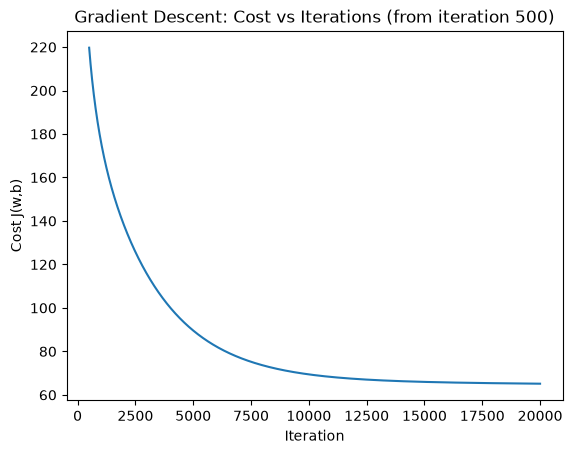

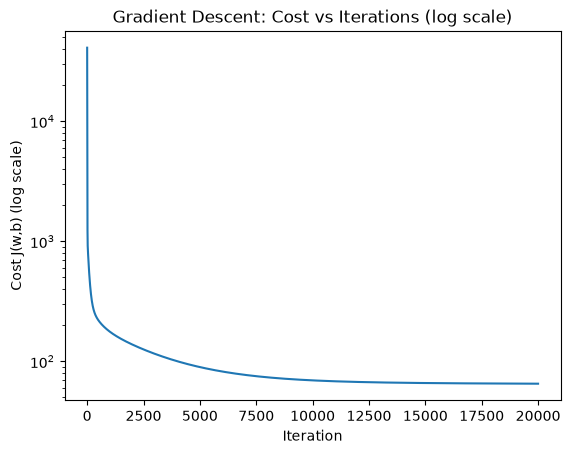

In [10]:
# Change this value to zoom into the cost curve.
# Use 0 to show all iterations.
# Try values like 100, 500, or 1000 to focus on later convergence.
start_iteration = 500

start_index = 0
for i in range(len(it_hist)):
    if it_hist[i] >= start_iteration:
        start_index = i
        break

fig, ax = plt.subplots()
ax.plot(it_hist[start_index:], cost_hist[start_index:])
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {start_iteration})")
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()

plt.figure()
plt.semilogy(it_hist, cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b) (log scale)")
plt.title("Gradient Descent: Cost vs Iterations (log scale)")
plt.show()


### 5.2 Compare Predicted vs True Prices

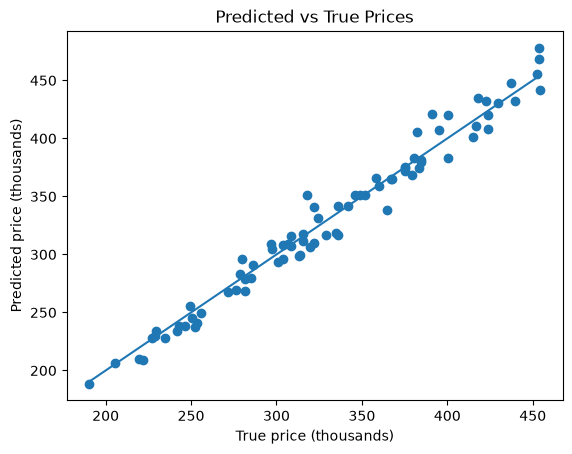

In [11]:
y_pred = predict(X, w_learned, b_learned)

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("True price (thousands)")
plt.ylabel("Predicted price (thousands)")
plt.title("Predicted vs True Prices")

# Diagonal reference line: perfect predictions would lie on this line.
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()


## 6. Feature Scaling

Gradient descent can be **slow** if the features have very different scales.

For example, in our dataset:

- `size_m2` might be around 50-200,
- `bedrooms` is around 1-4,
- `front_m` is around 5-15,
- `depth_m` is around 8-25.

A common solution is to **scale** each feature. Here we use **standardization**:

$$
x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}
$$

where $\mu_j$ is the mean of feature $j$, and $\sigma_j$ is its standard deviation.

After scaling, each feature has mean close to 0 and standard deviation close to 1. This often lets gradient descent use a larger learning rate.


In [12]:
def feature_scale(X):
    """Standardize each feature to have mean 0 and standard deviation 1."""
    # axis=0 means: compute one mean and one standard deviation per column.
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)

    # NumPy broadcasts means and stds across all rows of X.
    X_scaled = (X - means) / stds

    return X_scaled, means, stds


X_scaled, X_means, X_stds = feature_scale(X)
print("Feature means:", X_means)
print("Feature stds:", X_stds)
print("Scaled feature means:", X_scaled.mean(axis=0))
print("Scaled feature stds:", X_scaled.std(axis=0))


Feature means: [127.0189   2.6125  10.3945  17.1956]
Feature stds: [44.2109  1.1989  2.9194  5.0515]
Scaled feature means: [-0.  0. -0.  0.]
Scaled feature stds: [1. 1. 1. 1.]


### 6.1 Gradient Descent with and without Scaling

Without scaling, we use a small learning rate because some feature values are large.

With scaling, we can usually use a larger learning rate because the feature columns are on comparable scales.


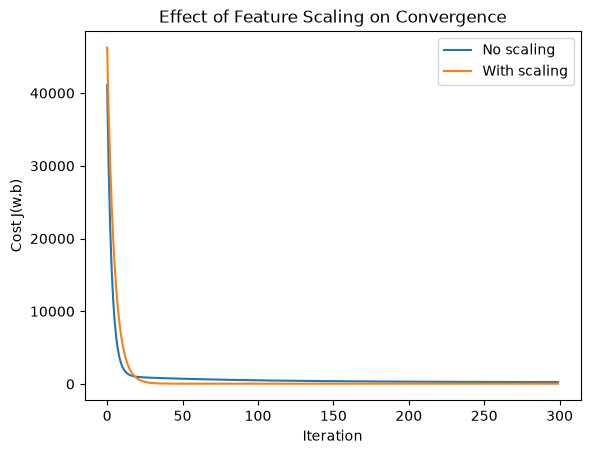

In [13]:
# Without scaling.
alpha_no_scale = 1e-4
w0 = np.zeros(n)
b0 = 0.0
w_ns, b_ns, it_ns, cost_ns = gradient_descent(X, y, w0, b0, alpha_no_scale, 300, print_progress=False)

# With scaling.
alpha_scale = 1e-1
w0_s = np.zeros(n)
b0_s = 0.0
w_s, b_s, it_s, cost_s = gradient_descent(X_scaled, y, w0_s, b0_s, alpha_scale, 300, print_progress=False)

plt.figure()
plt.plot(it_ns, cost_ns, label="No scaling")
plt.plot(it_s, cost_s, label="With scaling")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Effect of Feature Scaling on Convergence")
plt.legend()
plt.show()


## 7. Optional Extension: Feature Engineering

Sometimes we can create **new features** that better capture the structure of the problem.

Example for houses:

- The area of the lot is roughly `front_m * depth_m`.
- We can create a new feature:

$$
\text{area} = \text{front\_m} \times \text{depth\_m}
$$

This section is an extension. The main multifeature regression model already works without it.


In [14]:
area = data["front_m"].to_numpy() * data["depth_m"].to_numpy()
data["area_m2"] = area

# New design matrix with the added engineered feature.
X_fe = np.column_stack([
    data["size_m2"].to_numpy(),
    data["bedrooms"].to_numpy(),
    data["front_m"].to_numpy(),
    data["depth_m"].to_numpy(),
    data["area_m2"].to_numpy(),
])

feature_names_fe = feature_names + ["area_m2"]
n_fe = X_fe.shape[1]
X_fe_scaled, means_fe, stds_fe = feature_scale(X_fe)

w0_fe = np.zeros(n_fe)
b0_fe = 0.0
alpha_fe = 1e-1

w_fe, b_fe, it_fe, cost_fe = gradient_descent(X_fe_scaled, y, w0_fe, b0_fe, alpha_fe, 300, print_progress=False)

print("Learned parameters with engineered area feature, on scaled features:")
for name, value in zip(feature_names_fe, w_fe):
    print(f"{name:>10s}: {value:8.4f}")
print("bias b   :", b_fe)
print("Final cost:", cost_fe[-1])


Learned parameters with engineered area feature, on scaled features:
   size_m2:  67.3499
  bedrooms:  12.4934
   front_m:   8.4173
   depth_m:   9.5219
   area_m2:   0.0140
bias b   : 330.9013988653945
Final cost: 47.00348969675015


## 8. Optional Extension: Polynomial Regression

Linear regression can also model **non-linear relationships** by adding **polynomial features**.

Example: if price depends non-linearly on size, we can add $x_{size}^2$ as a new feature:

$$
f_{w,b}(x) = w_1\,\text{size} + w_2\,\text{size}^2 + b
$$

This is still linear in the parameters $w_1$, $w_2$, and $b$, so we can use the same algorithms.

This section is mainly about how to create polynomial features. Our simulated dataset is mostly linear, so the polynomial model is not guaranteed to be better.


In [15]:
size_only = data["size_m2"].to_numpy()
y_price = data["price_k"].to_numpy()

# Build a two-feature matrix: size and size squared.
X_poly = np.column_stack([size_only, size_only ** 2])
X_poly_scaled, means_poly, stds_poly = feature_scale(X_poly)

n_poly = X_poly_scaled.shape[1]
w0_poly = np.zeros(n_poly)
b0_poly = 0.0
alpha_poly = 1e-1

w_poly, b_poly, it_poly, cost_poly = gradient_descent(
    X_poly_scaled, y_price, w0_poly, b0_poly, alpha_poly, 500, print_progress=False
)

print("Learned parameters for polynomial regression, on scaled features:")
print("size:", w_poly[0])
print("size^2:", w_poly[1])
print("bias b:", b_poly)
print("Final cost:", cost_poly[-1])


Learned parameters for polynomial regression, on scaled features:
size: 44.050174342781105
size^2: 21.55638321992666
bias b: 330.9013988654005
Final cost: 163.0552255617233


### 8.1 Visualize Polynomial Fit

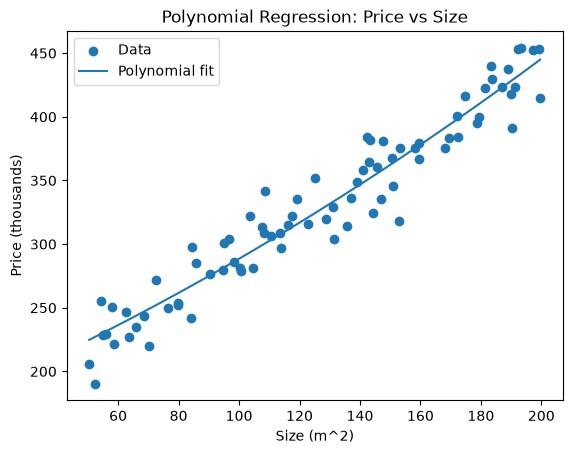

In [16]:

# Create a smooth grid of sizes for plotting the curve
size_grid = np.linspace(size_only.min(), size_only.max(), 200)
X_grid = np.column_stack([size_grid, size_grid ** 2])

# Apply same scaling as training
X_grid_scaled = (X_grid - means_poly) / stds_poly
y_grid_pred = predict(X_grid_scaled, w_poly, b_poly)

plt.figure()
plt.scatter(size_only, y_price, label="Data")
plt.plot(size_grid, y_grid_pred, label="Polynomial fit")
plt.xlabel("Size (m^2)")
plt.ylabel("Price (thousands)")
plt.title("Polynomial Regression: Price vs Size")
plt.legend()
plt.show()



## 9. Exercises (for You to Try)

1. **Change the learning rate $\alpha$** for the multifeature model:
   - Try values like `1e-3`, `5e-4`, `5e-2` (with scaling).
   - How does the convergence speed change? Does it diverge for some values?

2. **Try different engineered features**:
   - For example, try `size_per_bedroom = size_m2 / bedrooms` (be careful with division by zero).
   - Add it as an extra column and see if the cost decreases faster or to a smaller value.

3. **Compare models with and without the `area` feature**:
   - Train two models: one with features `[size, bedrooms, front, depth]` and one with `[size, bedrooms, front, depth, area]`.
   - Compare training cost and the scatter plot of true vs predicted prices.

4. **Increase the polynomial degree**:
   - Add a `size_m2^3` column and repeat the polynomial regression part.
   - Does the fit improve? Does it start to look like it is overfitting the noise?

5. **(Optional) Use a real dataset**:
   - If you have a CSV file with real house data, load it with `pandas.read_csv`,
   - Build the design matrix $X$ and target $y$,
   - Apply the same steps: scaling, gradient descent, feature engineering, and polynomial regression.
